# **sklearn pipeline**

### **imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

### **1. Load and explore dataset**

In [2]:
DATA_PATH = r"C:\Users\mrcoo\Machine-Learning-full-course-main\month_4\model_building_lesson_10\main\ai-impact-jobs-layoff-risk-dataset.csv"
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (20000, 16)


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [3]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Target Distribution:")
print(df["Layoff_Risk"].value_counts())

Missing values:
Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

Target Distribution:
Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64


In [4]:
print("Dtypes:")
print(df.dtypes)
print()
df.describe()

Dtypes:
Age                            int64
Education_Level               object
Years_of_Experience            int64
Industry                      object
Job_Role                      object
Company_Size                  object
Job_Level                     object
Routine_Task_Percentage        int64
Creativity_Requirement         int64
Human_Interaction_Level        int64
AI_Adoption_Level             object
Number_of_AI_Tools_Used        int64
AI_Usage_Hours_Per_Week        int64
Tasks_Automated_Percentage     int64
AI_Training_Hours              int64
Layoff_Risk                   object
dtype: object



,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


### **2.Custom Transformer - Ordinal Mapper**


In [5]:
class OrdinalMapper(BaseEstimator, TransformerMixin):
    def __init__(self, mapping: dict):
        self.mapping = mapping

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = np.array(X.columns, dtype=object)
        else:
            self.feature_names_in_ = np.array(['ordinal_feature'], dtype=object)
        self.is_fitted_ = True
        return self

    def transform(self, X, y=None):
        X_flat = pd.Series(np.array(X).ravel()).map(self.mapping)
        return X_flat.values.astype(float).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = getattr(self, 'feature_names_in_', ['ordinal_feature'])
        return np.array([f"{input_features[0]}_ordinal"], dtype=object)


mapper = OrdinalMapper({'Low': 0, 'Medium': 1, 'High': 2})
test_input = pd.DataFrame({'AI_Adoption_Level': ['Low', 'High', 'Medium']})
print('Input :', test_input['AI_Adoption_Level'].tolist())
print('Output:', mapper.fit_transform(test_input[['AI_Adoption_Level']]).ravel())
print('get_params():', mapper.get_params())

Input : ['Low', 'High', 'Medium']
Output: [0. 2. 1.]
get_params(): {'mapping': {'Low': 0, 'Medium': 1, 'High': 2}}


### **3.Column Definitions**

In [6]:
NUMERIC_FEATURES = [
    'Age', 'Years_of_Experience', 'Routine_Task_Percentage',
    'Creativity_Requirement', 'Human_Interaction_Level',
    'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week',
    'Tasks_Automated_Percentage', 'AI_Training_Hours',
]


ORDINAL_CONFIG = {
    'AI_Adoption_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Job_Level':         {'Entry': 0, 'Mid': 1, 'Senior': 2},
    'Company_Size':      {'Small': 0, 'Medium': 1, 'Large': 2},
}


NOMINAL_FEATURES = ['Education_Level', 'Industry', 'Job_Role']
TARGET = 'Layoff_Risk'

print('Numeric :', NUMERIC_FEATURES)
print('Ordinal :', list(ORDINAL_CONFIG.keys()))
print('Nominal :', NOMINAL_FEATURES)

Numeric : ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']
Ordinal : ['AI_Adoption_Level', 'Job_Level', 'Company_Size']
Nominal : ['Education_Level', 'Industry', 'Job_Role']


### **4. SimpleImputer - fill missing values**
__Even though this dataset has no NaN, we need an imputer in production.
The imputer learns fill values from `X_train`; `transform()` applies them to test data (no leakage).__

In [7]:
sample = df[NUMERIC_FEATURES].copy()
sample.loc[0, 'Age'] = np.nan
print('NaN before:', sample.isnull().sum().sum())

imp = SimpleImputer(strategy='median')
out = imp.fit_transform(sample)
print('NaN after :', np.isnan(out).sum())
print('Learned medians:', imp.statistics_[:4], '...')

NaN before: 1
NaN after : 0
Learned medians: [40.  7. 52. 48.] ...


### **5. Pipeline - chain steps per column group**

In [8]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

def make_ordinal_pipeline(mapping):
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('mapper',  OrdinalMapper(mapping)),
    ])

print('Numeric pipeline:')
print(numeric_pipeline)
print()
print('Nominal pipeline:')
print(nominal_pipeline)

Numeric pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Nominal pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


### **6.ColumnTransformer - different transforms per column group**

All sub-pipelines are declared flat (one level). Each ordinal column gets its own named entry because each has a different mapping.

In [9]:
transformers = [
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('nom', nominal_pipeline, NOMINAL_FEATURES),
]
for col, mapping in ORDINAL_CONFIG.items():
    transformers.append((f'ord_{col}', make_ordinal_pipeline(mapping), [col]))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Test it on a small sample
X_sample = df.drop(columns=[TARGET]).head(50)
out = preprocessor.fit_transform(X_sample)
print('Input shape :', X_sample.shape)
print('Output shape:', out.shape)  # 9 numeric + OHE-expanded nominal + 3 ordinal

Input shape : (50, 15)
Output shape: (50, 44)


### **7.Full pipeline (preprocessor + model)**

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Rebuild preprocessor fresh (not the one fitted on sample above)
transformers2 = [
    ('num', numeric_pipeline, NUMERIC_FEATURES),
    ('nom', nominal_pipeline, NOMINAL_FEATURES),
]
for col, mapping in ORDINAL_CONFIG.items():
    transformers2.append((f'ord_{col}', make_ordinal_pipeline(mapping), [col]))
preprocessor2 = ColumnTransformer(transformers=transformers2, remainder='drop')

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('model', RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    )),
])

full_pipeline.fit(X_train, y_train)
preds = full_pipeline.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

        High       0.90      0.92      0.91      1360
         Low       0.91      0.90      0.90      1320
      Medium       0.81      0.81      0.81      1320

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



### **8.Confusion Matrix**

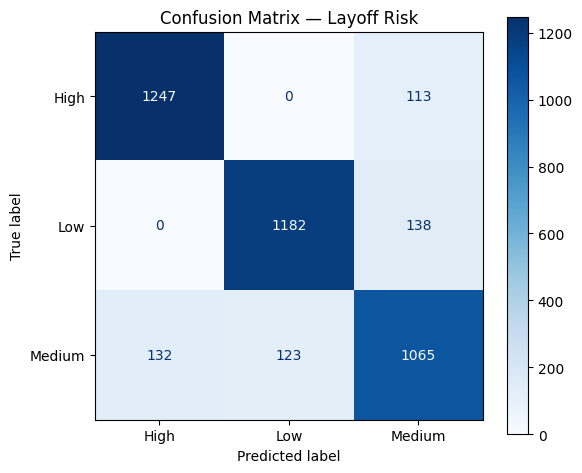

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels=full_pipeline.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Layoff Risk')
plt.tight_layout()
plt.show()

### **9.Feature Importances**

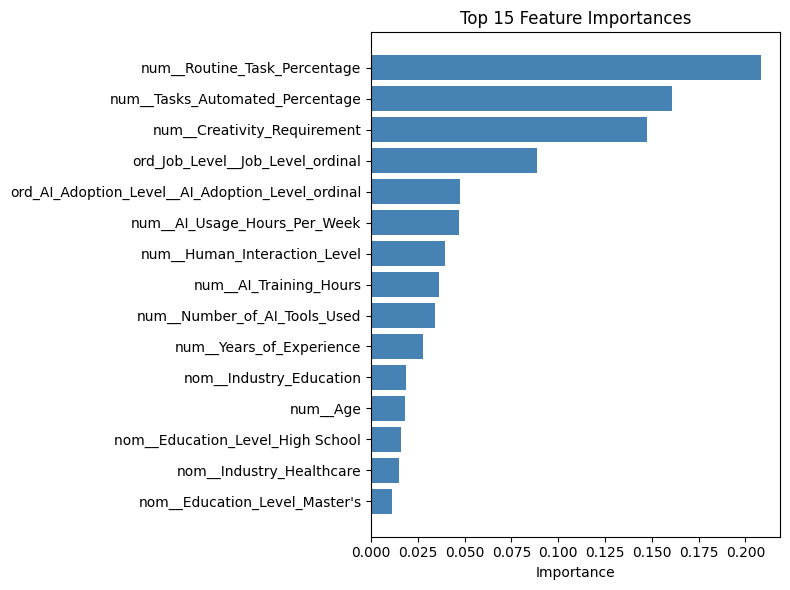

In [12]:
rf = full_pipeline.named_steps['model']
pre = full_pipeline.named_steps['preprocessor']

# Get feature names from ColumnTransformer
feature_names = pre.get_feature_names_out()
importances = rf.feature_importances_

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

### **10. Predict On New Employees**

In [13]:
new_employees = [
    {  # High routine, many AI tools → expect High risk
        'Age': 28, 'Education_Level': "Bachelor's",
        'Years_of_Experience': 3, 'Industry': 'IT',
        'Job_Role': 'Software Engineer', 'Company_Size': 'Large',
        'Job_Level': 'Entry', 'Routine_Task_Percentage': 70,
        'Creativity_Requirement': 30, 'Human_Interaction_Level': 20,
        'AI_Adoption_Level': 'High', 'Number_of_AI_Tools_Used': 8,
        'AI_Usage_Hours_Per_Week': 30, 'Tasks_Automated_Percentage': 60,
        'AI_Training_Hours': 5,
    },
    {  # Low routine, PhD, high creativity → expect Low risk
        'Age': 45, 'Education_Level': 'PhD',
        'Years_of_Experience': 18, 'Industry': 'Finance',
        'Job_Role': 'Auditor', 'Company_Size': 'Medium',
        'Job_Level': 'Senior', 'Routine_Task_Percentage': 20,
        'Creativity_Requirement': 80, 'Human_Interaction_Level': 70,
        'AI_Adoption_Level': 'Low', 'Number_of_AI_Tools_Used': 1,
        'AI_Usage_Hours_Per_Week': 3, 'Tasks_Automated_Percentage': 10,
        'AI_Training_Hours': 40,
    },
]

df_new = pd.DataFrame(new_employees)
preds_new  = full_pipeline.predict(df_new)
proba_new  = full_pipeline.predict_proba(df_new)

result = df_new[['Job_Role', 'Industry']].copy()
result['Predicted_Risk'] = preds_new
for i, cls in enumerate(full_pipeline.classes_):
    result[f'P({cls})'] = proba_new[:, i].round(3)
result

,Job_Role,Industry,Predicted_Risk,P(High),P(Low),P(Medium)
0,Software Engineer,IT,High,0.819,0.008,0.173
1,Auditor,Finance,Low,0.003,0.913,0.085


---
## Summary

| Component | Role in this pipeline |
|---|---|
| `OrdinalMapper` (custom) | Converts Low/Medium/High → 0/1/2 for ordinal cols |
| `SimpleImputer` | Fills NaN (median for numeric, most_frequent for categorical) |
| `StandardScaler` | Z-score normalises numeric features |
| `OneHotEncoder` | Expands nominal strings into binary columns |
| `Pipeline` | Chains steps; prevents data leakage |
| `ColumnTransformer` | Routes each column group to the right sub-pipeline |
| `RandomForestClassifier` | Final model (87% accuracy, Low/Medium/High risk) |

**sklearn ≥ 1.6 rule:** always set `self.is_fitted_ = True` in custom transformer `fit()` methods.